# Code to analyze CAMELS-CL data for the Itata Basin (Nevados de Chillán)
## Precipitation, temperature, streamflow, and water rights sales 
### all CAMELS-CL basin data is freely available here: https://camels.cr2.cl/

CAMELS-CL Data Citation: 
Alvarez-Garreton, C., Mendoza, P. A., Boisier, J. P., Addor, N., Galleguillos, M., Zambrano-Bigiarini, M., Lara, A., Puelma, C., Cortes, G., Garreaud, R., McPhee, J., and Ayala, A.: The CAMELS-CL dataset: catchment attributes and meteorology for large sample studies – Chile dataset, Hydrol. Earth Syst. Sci., 22, 5817-5846, https://doi.org/10.5194/hess-22-5817-2018 , 2018.

In [115]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from datetime import datetime
from geopy.distance import geodesic
import seaborn as sns
from scipy.stats import linregress

Distance between glacier and met station: 18.07 km
Elevation difference: 1899 m


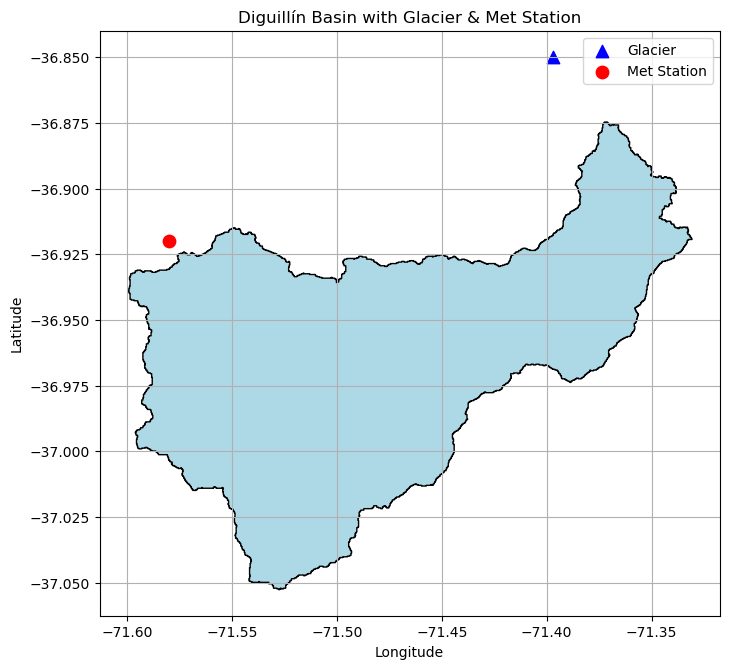

In [116]:
# path to basin shapefile
shapefile_path = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/polygon/polygon.shp' 
# File paths for your CAMELS basin data
# Here using: Cuenca 8130002 - Rio Diguillin En San Lorenzo (Atacalco) (Lat. -36.92, Lon. -71.58)
# Área: 204.4 km². Precip. anual media CR2MET: 2400 mm. Indice áridez: 0.4
# Cota (máx., media, punto salida): 3176, 1511, 715 m s.n.m.

# Load the shapefile using GeoPandas
basin_gdf = gpd.read_file(shapefile_path)

# Glacier and station coordinates (lat, lon)
glacier_coords = (-36.85, -71.397)   # (Lat, Lon)
station_coords = (-36.92, -71.58)    # (Lat, Lon)

# Elevations in meters
glacier_elev = 2614
station_elev = 715

# Calculate aerial distance (in km)
distance_km = geodesic(glacier_coords, station_coords).km

# Calculate elevation difference (in m)
elev_diff = glacier_elev - station_elev

print(f"Distance between glacier and met station: {distance_km:.2f} km")
print(f"Elevation difference: {elev_diff} m")

# Plot the basin polygon
fig, ax = plt.subplots(figsize=(8, 8))
basin_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Plot glacier location
ax.scatter(glacier_coords[1], glacier_coords[0], color='blue', s=80, marker='^', label="Glacier")

# Plot meteorological station location
ax.scatter(station_coords[1], station_coords[0], color='red', s=80, marker='o', label="Met Station")

# Add labels and grid
ax.set_title("Diguillín Basin with Glacier & Met Station")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.legend()

plt.show()


## script to check timeseries for autocorrelation, analyze annual and seasonal trends 

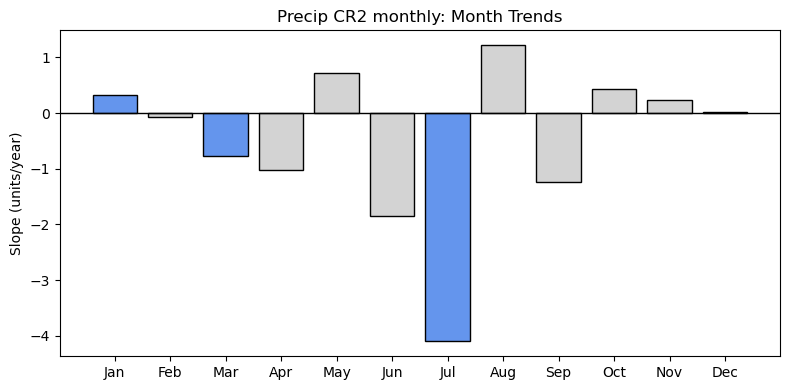


Month trends for Precip CR2 monthly (units):
    month     slope   p_value  significant  n_years
0       1  0.333778  0.025163         True       42
1       2 -0.068259  0.836851        False       42
2       3 -0.774621  0.065423         True       42
3       4 -1.026510  0.200963        False       42
4       5  0.725517  0.908876        False       41
5       6 -1.849545  0.438337        False       41
6       7 -4.101110  0.098719         True       41
7       8  1.221720  0.629115        False       41
8       9 -1.237003  0.451726        False       41
9      10  0.431243  0.831010        False       41
10     11  0.243252  0.677716        False       41
11     12  0.020261  0.857347        False       41


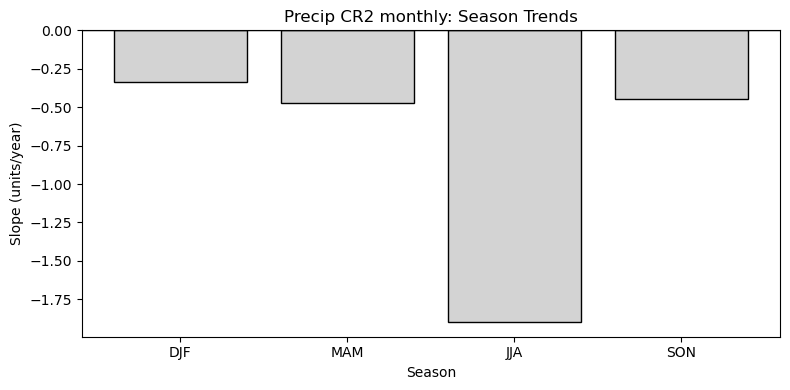


Season trends for Precip CR2 monthly (units):
           slope   p_value  significant  n_years
season                                          
DJF    -0.338745  0.224829        False       42
MAM    -0.472636  0.648878        False       42
JJA    -1.898469  0.275934        False       41
SON    -0.446445  0.694232        False       41
Annual trend for 8130002: slope=-1.8234, p=0.007, significant=True


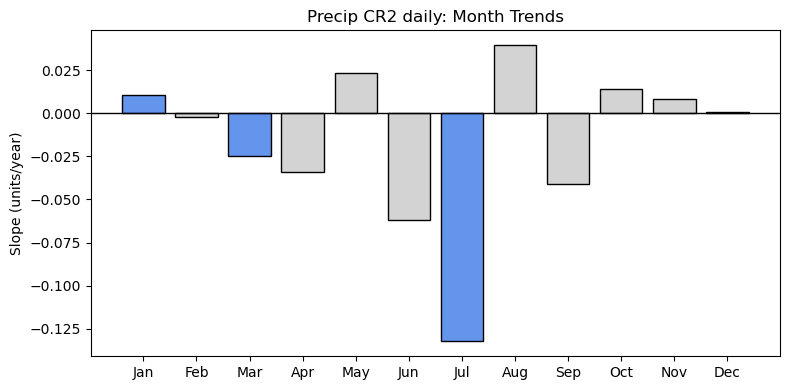


Month trends for Precip CR2 daily (units):
    month     slope   p_value  significant  n_years
0       1  0.010767  0.025163         True       42
1       2 -0.002243  0.853820        False       42
2       3 -0.024988  0.065423         True       42
3       4 -0.034217  0.200963        False       42
4       5  0.023404  0.908876        False       41
5       6 -0.061652  0.438337        False       41
6       7 -0.132294  0.098719         True       41
7       8  0.039410  0.629115        False       41
8       9 -0.041233  0.451726        False       41
9      10  0.013911  0.831010        False       41
10     11  0.008108  0.677716        False       41
11     12  0.000654  0.857347        False       41


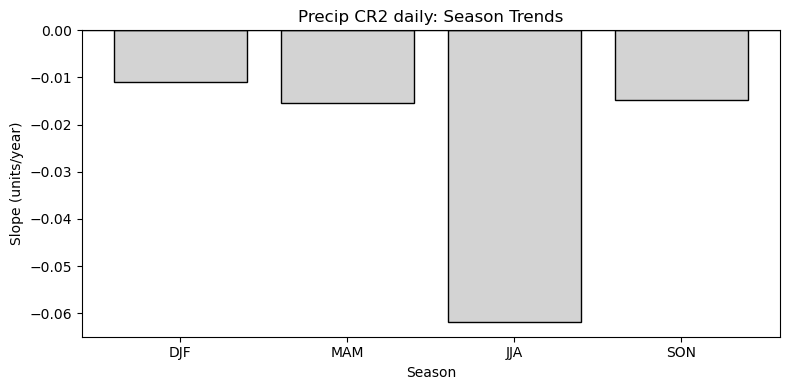


Season trends for Precip CR2 daily (units):
           slope   p_value  significant  n_years
season                                          
DJF    -0.010945  0.233217        False       42
MAM    -0.015412  0.648878        False       42
JJA    -0.061907  0.275934        False       41
SON    -0.014718  0.694232        False       41
Annual trend for 8130002: slope=-0.0596, p=0.007, significant=True


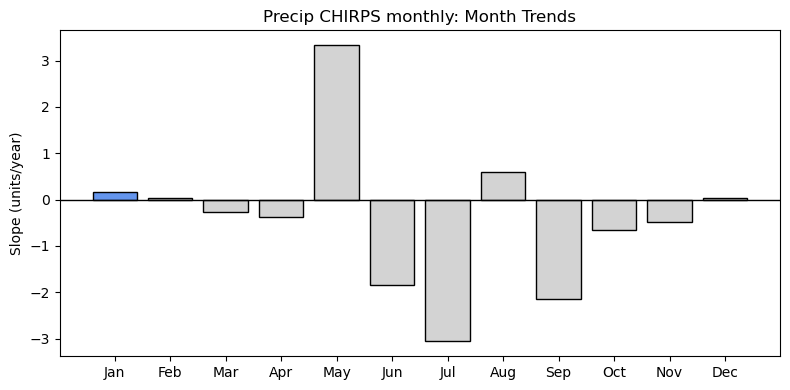


Month trends for Precip CHIRPS monthly (units):
    month     slope   p_value  significant  n_years
0       1  0.164296  0.001185         True       39
1       2  0.029636  0.903716        False       39
2       3 -0.269375  0.309564        False       39
3       4 -0.379699  0.121512        False       39
4       5  3.331981  0.645745        False       39
5       6 -1.852621  0.424642        False       39
6       7 -3.061967  0.153456        False       39
7       8  0.592394  0.753127        False       39
8       9 -2.150667  0.255494        False       39
9      10 -0.653857  0.345397        False       39
10     11 -0.479536  0.198828        False       39
11     12  0.028200  0.980698        False       39


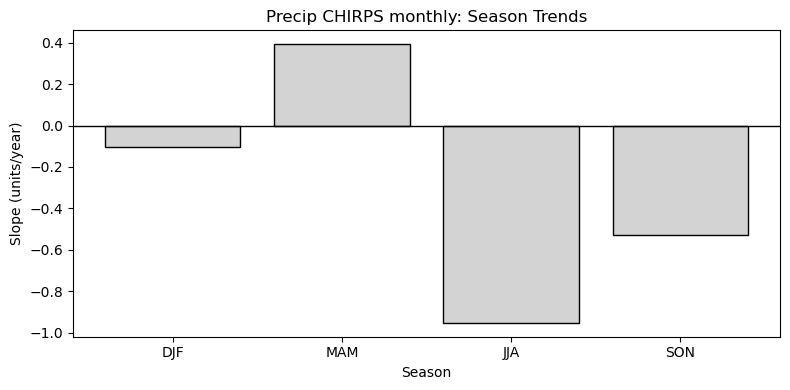


Season trends for Precip CHIRPS monthly (units):
           slope   p_value  significant  n_years
season                                          
DJF    -0.102889  0.513607        False       39
MAM     0.391936  0.827629        False       39
JJA    -0.951357       NaN        False       39
SON    -0.526123  0.498136        False       39
Annual trend for 8130002: slope=-0.4431, p=0.735, significant=False


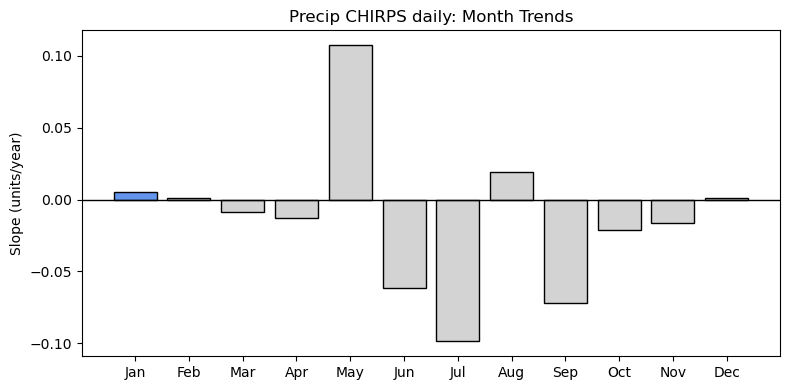


Month trends for Precip CHIRPS daily (units):
    month     slope   p_value  significant  n_years
0       1  0.005300  0.001185         True       39
1       2  0.001110  0.865516        False       39
2       3 -0.008690  0.309564        False       39
3       4 -0.012657  0.121512        False       39
4       5  0.107483  0.645745        False       39
5       6 -0.061754  0.424642        False       39
6       7 -0.098773  0.153456        False       39
7       8  0.019109  0.753127        False       39
8       9 -0.071689  0.255494        False       39
9      10 -0.021092  0.345397        False       39
10     11 -0.015985  0.198828        False       39
11     12  0.000910  0.980698        False       39


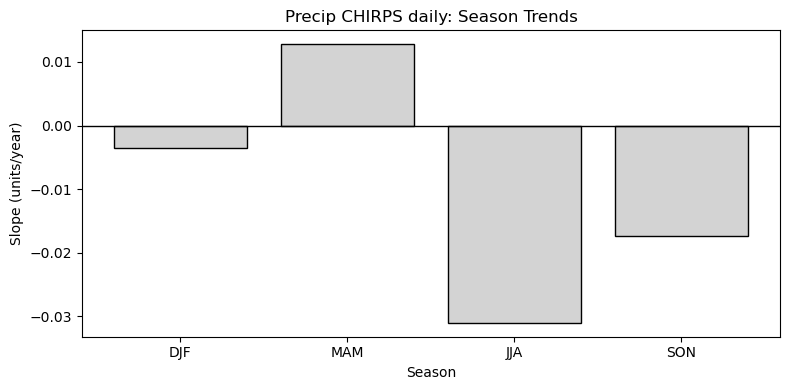


Season trends for Precip CHIRPS daily (units):
           slope   p_value  significant  n_years
season                                          
DJF    -0.003514  0.498136        False       39
MAM     0.012781  0.827629        False       39
JJA    -0.031023       NaN        False       39
SON    -0.017345  0.498136        False       39
Annual trend for 8130002: slope=-0.0121, p=0.734, significant=False


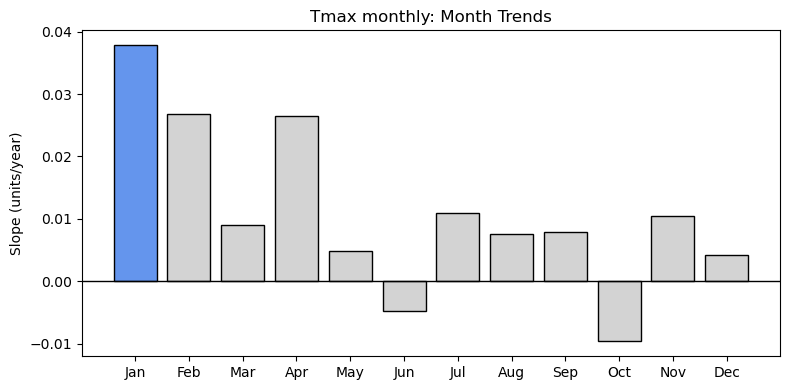


Month trends for Tmax monthly (units):
    month     slope   p_value  significant  n_years
0       1  0.037847  0.014315         True       42
1       2  0.026808  0.140513        False       42
2       3  0.008993  0.728744        False       42
3       4  0.026552  0.172092        False       42
4       5  0.004831  0.886136        False       41
5       6 -0.004777  0.831010        False       41
6       7  0.010919  0.396544        False       41
7       8  0.007619  0.437783        False       41
8       9  0.007857  0.694232        False       41
9      10 -0.009672  0.412255        False       41
10     11  0.010468  0.694232        False       41
11     12  0.004242  0.813533        False       41


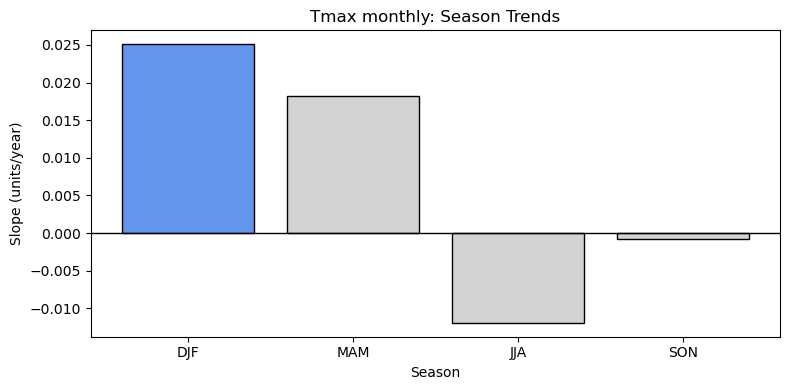


Season trends for Tmax monthly (units):
           slope   p_value  significant  n_years
season                                          
DJF     0.025092  0.030198         True       42
MAM     0.018252  0.553397        False       42
JJA    -0.011925  0.362935        False       41
SON    -0.000751  0.973120        False       41
Annual trend for 8130002: slope=0.0070, p=nan, significant=False


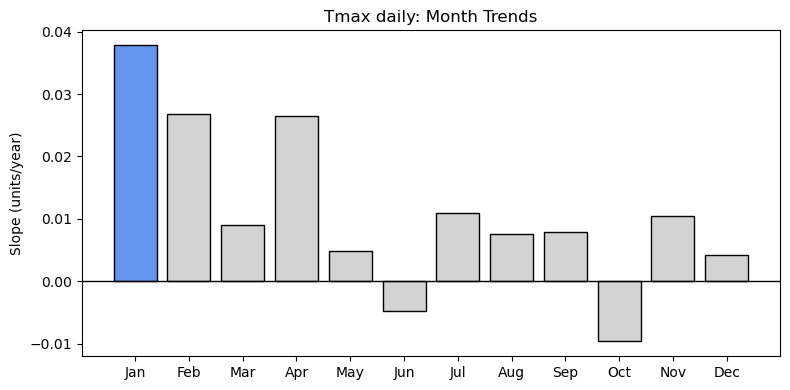


Month trends for Tmax daily (units):
    month     slope   p_value  significant  n_years
0       1  0.037847  0.014315         True       42
1       2  0.026808  0.140513        False       42
2       3  0.008993  0.728744        False       42
3       4  0.026552  0.172092        False       42
4       5  0.004831  0.886136        False       41
5       6 -0.004777  0.831010        False       41
6       7  0.010919  0.396544        False       41
7       8  0.007619  0.437783        False       41
8       9  0.007857  0.694232        False       41
9      10 -0.009672  0.412255        False       41
10     11  0.010468  0.694232        False       41
11     12  0.004242  0.813533        False       41


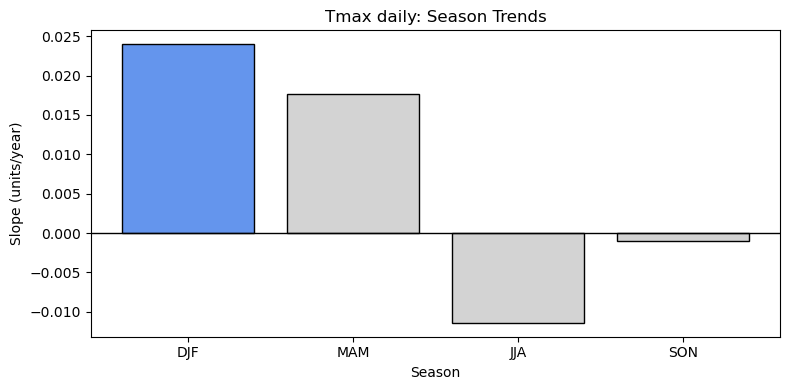


Season trends for Tmax daily (units):
           slope   p_value  significant  n_years
season                                          
DJF     0.023971  0.028586         True       42
MAM     0.017691  0.578653        False       42
JJA    -0.011403  0.351207        False       41
SON    -0.000994  0.973120        False       41
Annual trend for 8130002: slope=0.0077, p=nan, significant=False


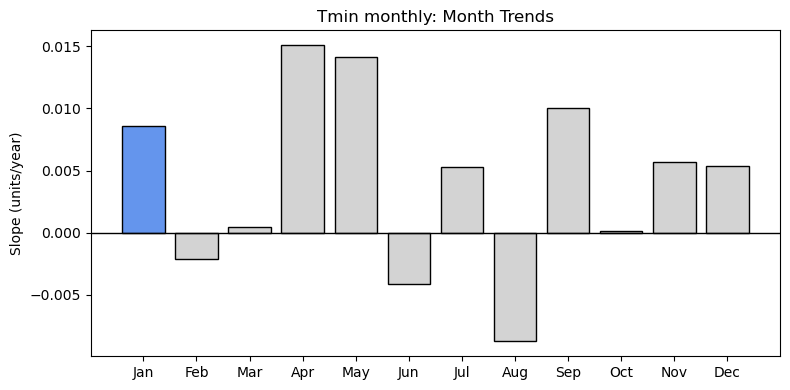


Month trends for Tmin monthly (units):
    month     slope   p_value  significant  n_years
0       1  0.008595  0.066928         True       42
1       2 -0.002071  0.839687        False       42
2       3  0.000445  0.946466        False       42
3       4  0.015084  0.179001        False       42
4       5  0.014162  0.296222        False       41
5       6 -0.004079  0.727697        False       41
6       7  0.005277  0.645446        False       41
7       8 -0.008738  0.629115        False       41
8       9  0.010027  0.479186        False       41
9      10  0.000132  0.991038        False       41
10     11  0.005701  0.629115        False       41
11     12  0.005398  0.778865        False       41


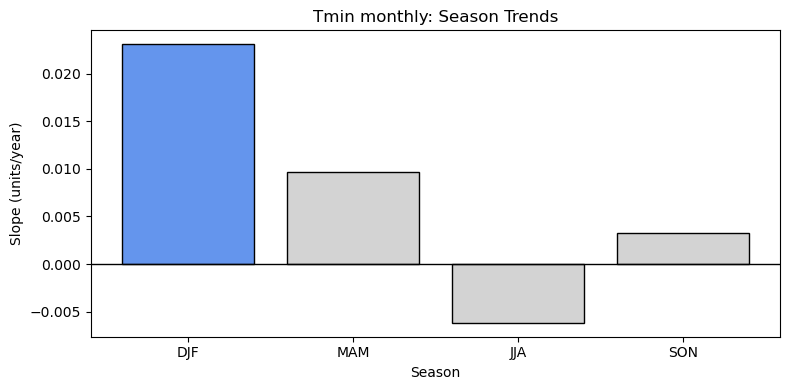


Season trends for Tmin monthly (units):
           slope   p_value  significant  n_years
season                                          
DJF     0.023106  0.004837         True       42
MAM     0.009638  0.241825        False       42
JJA    -0.006180  0.412255        False       41
SON     0.003238  0.727697        False       41
Annual trend for 8130002: slope=0.0073, p=0.051, significant=True


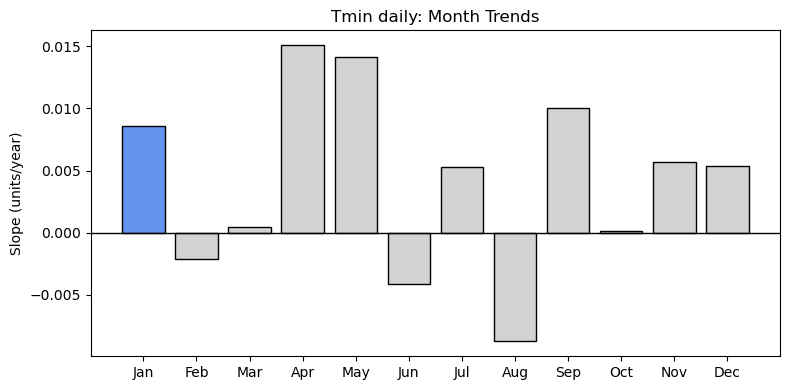


Month trends for Tmin daily (units):
    month     slope   p_value  significant  n_years
0       1  0.008595  0.066167         True       42
1       2 -0.002071  0.839687        False       42
2       3  0.000445  0.946466        False       42
3       4  0.015084  0.179001        False       42
4       5  0.014162  0.296222        False       41
5       6 -0.004079  0.727697        False       41
6       7  0.005277  0.645446        False       41
7       8 -0.008738  0.629115        False       41
8       9  0.010027  0.479186        False       41
9      10  0.000132  0.991038        False       41
10     11  0.005701  0.629115        False       41
11     12  0.005398  0.778865        False       41


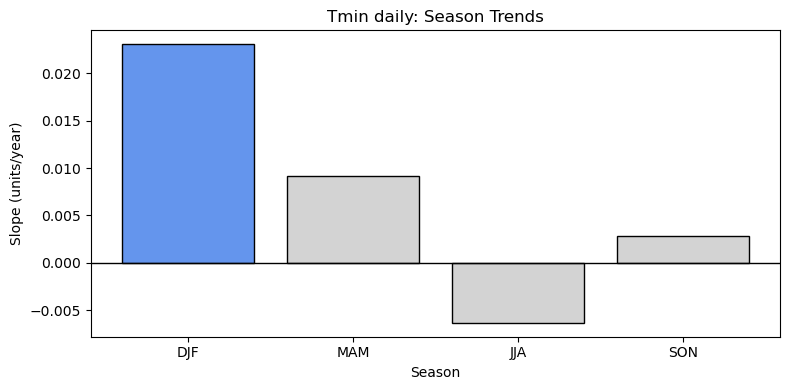


Season trends for Tmin daily (units):
           slope   p_value  significant  n_years
season                                          
DJF     0.023063  0.005173         True       42
MAM     0.009156  0.250654        False       42
JJA    -0.006318  0.374905        False       41
SON     0.002810  0.761690        False       41
Annual trend for 8130002: slope=0.0073, p=0.049, significant=True


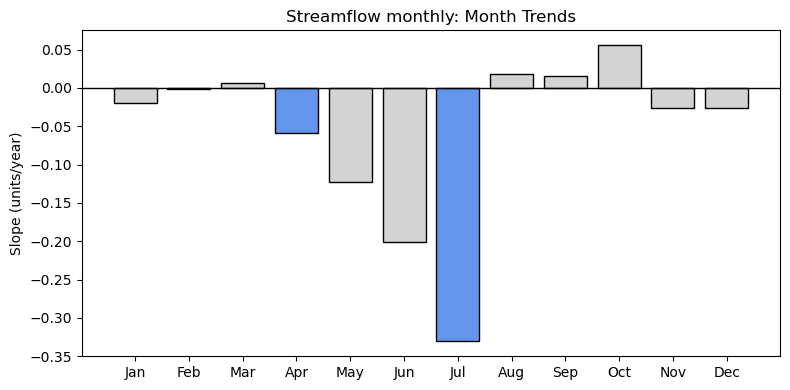


Month trends for Streamflow monthly (units):
    month     slope   p_value  significant  n_years
0       1 -0.020094  0.357010        False       41
1       2 -0.001918       NaN        False       40
2       3  0.006075       NaN        False       39
3       4 -0.059042  0.057670         True       41
4       5 -0.122760  0.724830        False       40
5       6 -0.200692  0.339722        False       41
6       7 -0.330723  0.074650         True       40
7       8  0.017611  0.922905        False       39
8       9  0.016067  0.903716        False       39
9      10  0.055733  0.645745        False       39
10     11 -0.026467  0.743767        False       38
11     12 -0.026667  0.706057        False       38


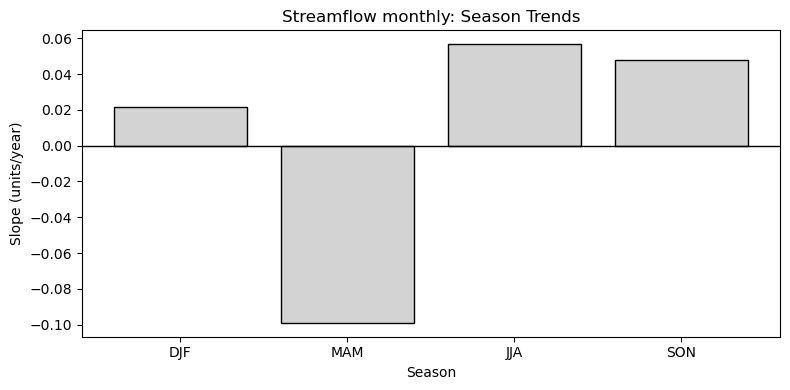


Season trends for Streamflow monthly (units):
           slope   p_value  significant  n_years
season                                          
DJF     0.021697  0.514546        False       41
MAM    -0.098875  0.541509        False       41
JJA     0.056611       NaN        False       41
SON     0.048062  0.734826        False       39
Annual trend for 8130002: slope=-0.0211, p=nan, significant=False


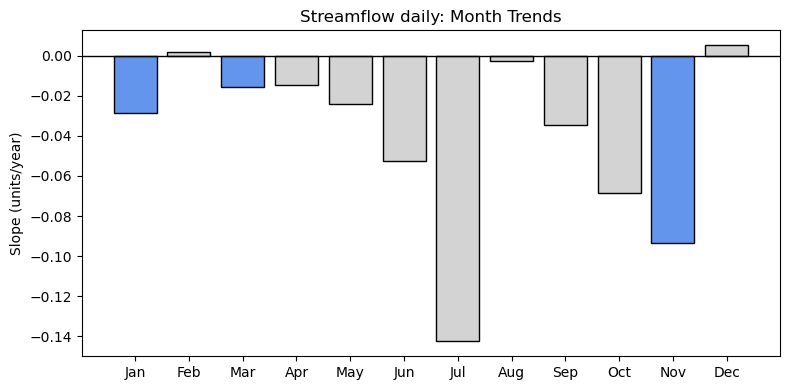


Month trends for Streamflow daily (units):
    month     slope   p_value  significant  n_years
0       1 -0.028517  0.009711         True       73
1       2  0.002122       NaN        False       72
2       3 -0.015311  0.051565         True       70
3       4 -0.014543  0.146359        False       73
4       5 -0.024026  0.864763        False       74
5       6 -0.052767  0.558205        False       75
6       7 -0.142663  0.101372        False       72
7       8 -0.002492  0.965103        False       72
8       9 -0.034402  0.472071        False       73
9      10 -0.068283  0.126336        False       73
10     11 -0.093489  0.015690         True       72
11     12  0.005352  0.341736        False       72


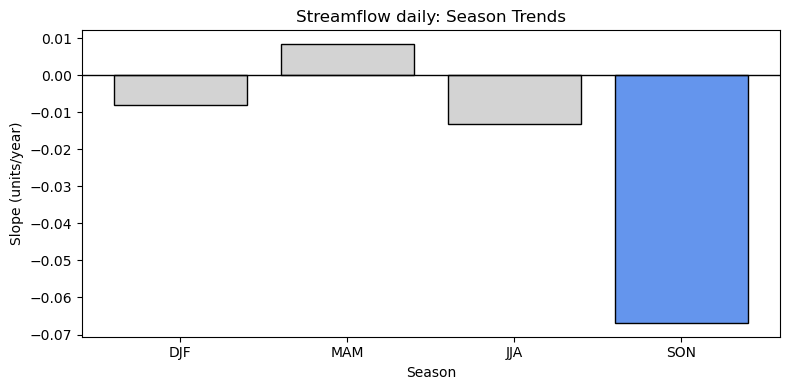


Season trends for Streamflow daily (units):
           slope   p_value  significant  n_years
season                                          
DJF    -0.008029  0.748816        False       75
MAM     0.008372       NaN        False       74
JJA    -0.013207       NaN        False       75
SON    -0.066830  0.089102         True       73
Annual trend for 8130002: slope=-0.0026, p=0.850, significant=False


In [133]:
# ============================================================
# Seasonal & Monthly Trend Analysis with Pre-Whitening + CSV
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import warnings
warnings.filterwarnings("ignore")

# ------------------- FILE PATHS -------------------
datasets = {
    "Precip CR2 monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_cr2met_mon.csv",
    "Precip CR2 daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_cr2met_day.csv",
    "Precip CHIRPS monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_chirps_mon.csv",
    "Precip CHIRPS daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_chirps_day.csv",
    "Tmax monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmax_cr2met_mon.csv",
    "Tmax daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmax_cr2met_day.csv",
    "Tmin monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmin_cr2met_mon.csv",
    "Tmin daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmin_cr2met_day.csv",
    "Streamflow monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/q_m3s_mon.csv",
    "Streamflow daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/q_m3s_day.csv"
}

basin_col = '8130002'
date_column = 'date'

# ------------------- FUNCTIONS -------------------

def load_data(filepath, value_col):
    df = pd.read_csv(filepath, parse_dates=[date_column])
    df = df[[date_column, value_col]].dropna()
    return df

def assign_season(df):
    df["month"] = df[date_column].dt.month
    df["season"] = df["month"].map({
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON"
    })
    df["year"] = df[date_column].dt.year
    return df

def check_serial_correlation(series):
    return series.autocorr(lag=1)

def prewhiten_series(series, lag1_acf):
    return series.diff().fillna(0) / (1 - lag1_acf)

def compute_trends(series):
    lag1 = check_serial_correlation(series)
    method = "Original"
    if lag1 > 0.1:
        series_pw = prewhiten_series(series, lag1)
        test = mk.hamed_rao_modification_test(series_pw.values)
        method = "Hamed-Rao (pre-whitened)"
    else:
        test = mk.original_test(series.values)
    return {
        "sen_slope": test.slope,
        "p_value": test.p,
        "trend": test.trend,
        "significant": test.p < 0.1,
        "n": len(series),
        "lag1_acf": lag1,
        "method": method
    }

def seasonal_trends(df, value_col):
    results = {}
    for season in ["DJF","MAM","JJA","SON"]:
        sub = df[df["season"]==season]
        if "precip" in value_col or "q" in value_col:
            series = sub.groupby("year")[value_col].sum().dropna()
        else:
            series = sub.groupby("year")[value_col].mean().dropna()
        if len(series) > 10:
            results[season] = compute_trends(series)
        else:
            results[season] = {"trend": "insufficient data"}
    return results

def annual_trends(df, value_col):
    if "precip" in value_col or "q" in value_col:
        series = df.groupby(df[date_column].dt.year)[value_col].sum().dropna()
    else:
        series = df.groupby(df[date_column].dt.year)[value_col].mean().dropna()
    if len(series) > 10:
        res = compute_trends(series)
        print(f"Annual trend for {value_col}: slope={res['sen_slope']:.4f}, "
              f"p={res['p_value']:.3f}, significant={res['significant']}")
    else:
        print(f"Annual trend for {value_col}: insufficient data")

def compute_monthly_trends(df, value_col):
    trends = []
    for month in range(1,13):
        sub = df[df[date_column].dt.month==month]
        if len(sub) > 10:
            series = sub.groupby(sub[date_column].dt.year)[value_col].mean()
            res = compute_trends(series)
            trends.append({
                "month": month,
                "slope": res["sen_slope"],
                "p_value": res["p_value"],
                "significant": res["significant"],
                "n_years": res["n"]
            })
        else:
            trends.append({
                "month": month,
                "slope": np.nan,
                "p_value": np.nan,
                "significant": False,
                "n_years": len(sub)
            })
    return pd.DataFrame(trends)

def compute_seasonal_trends(df, value_col):
    trends = []
    for season in ["DJF","MAM","JJA","SON"]:
        sub = df[df["season"]==season]
        if len(sub) > 10:
            series = sub.groupby(sub["year"])[value_col].mean()
            res = compute_trends(series)
            trends.append({
                "season": season,
                "slope": res["sen_slope"],
                "p_value": res["p_value"],
                "significant": res["significant"],
                "n_years": res["n"]
            })
        else:
            trends.append({
                "season": season,
                "slope": np.nan,
                "p_value": np.nan,
                "significant": False,
                "n_years": len(sub)
            })
    return pd.DataFrame(trends).set_index("season")

def plot_trends(df_trends, label, timescale, units):
    fig, ax = plt.subplots(figsize=(8,4))
    
    # Color: blue if significant, gray if not
    colors = ['cornflowerblue' if sig else 'lightgray' for sig in df_trends['significant']]
    
    if timescale=="month":
        x = df_trends["month"]
    else:
        x = df_trends.index
    y = df_trends["slope"]
    
    ax.bar(x, y, color=colors, edgecolor='k')
    ax.axhline(0, color='k', linewidth=1)
    
    ax.set_title(f"{label}: {timescale.capitalize()} Trends")
    ax.set_ylabel(f"Slope ({units}/year)")
    if timescale=="month":
        ax.set_xticks(range(1,13))
        ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
    else:
        ax.set_xlabel(timescale.capitalize())
    
    plt.tight_layout()
    plt.show()
    print(f"\n{timescale.capitalize()} trends for {label} ({units}):")
    print(df_trends)

# ------------------- RUN TREND ANALYSIS & PLOTS -------------------

for name, path in datasets.items():
    df = load_data(path, basin_col)
    df = assign_season(df)
    
    # Monthly trends
    df_month_trends = compute_monthly_trends(df, basin_col)
    plot_trends(df_month_trends, name, "month", "units")
    
    # Seasonal trends
    df_season_trends = compute_seasonal_trends(df, basin_col)
    plot_trends(df_season_trends, name, "season", "units")
    
    # Annual trend (just print slope and significance)
    annual_trends(df, basin_col)


## Timeseries analysis 


=== Precip CR2 monthly ===


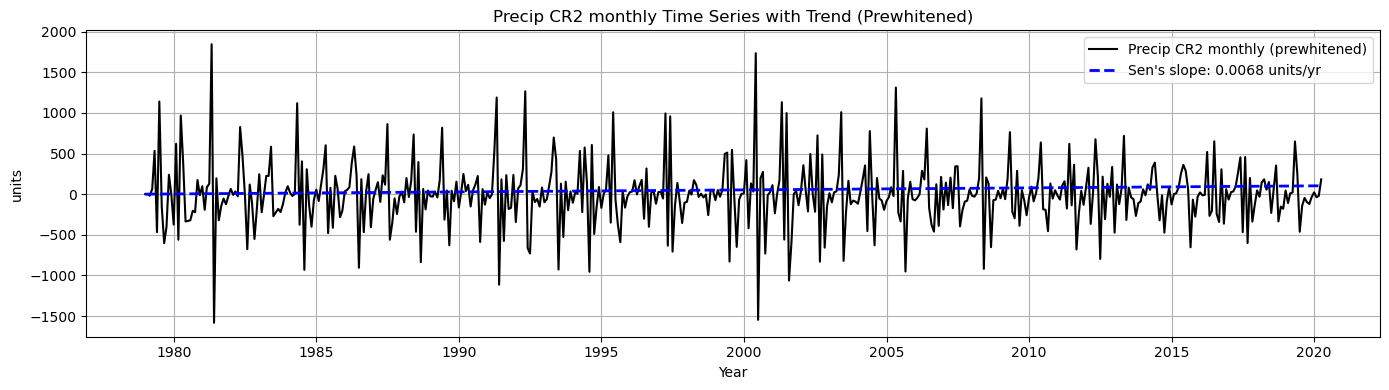


=== Annual trend for Precip CR2 monthly ===
Sen's slope: -1.8234 units/year
Significant (p<0.1)? Yes
Pre-whitening used: Original

=== Precip CHIRPS daily ===


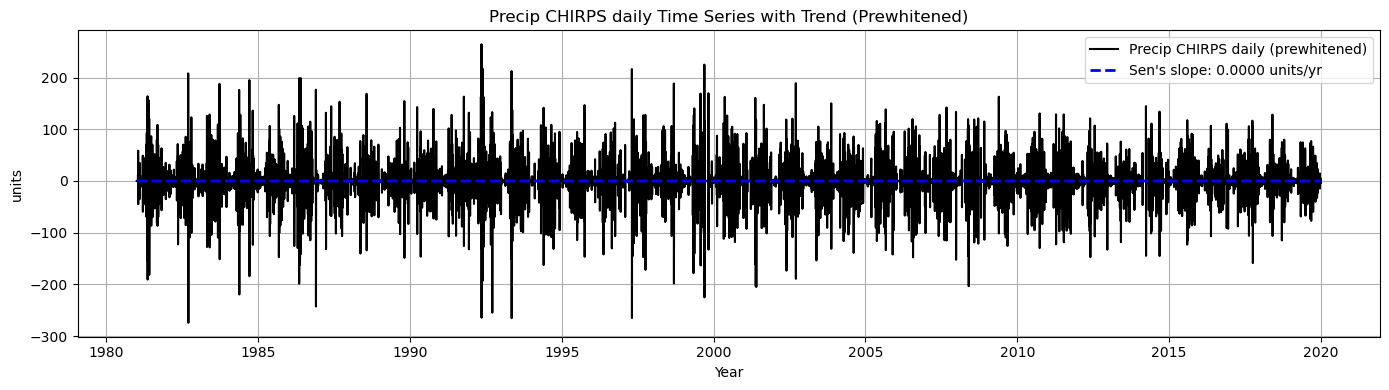


=== Annual trend for Precip CHIRPS daily ===
Sen's slope: -0.0121 units/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened

=== Tmax monthly ===


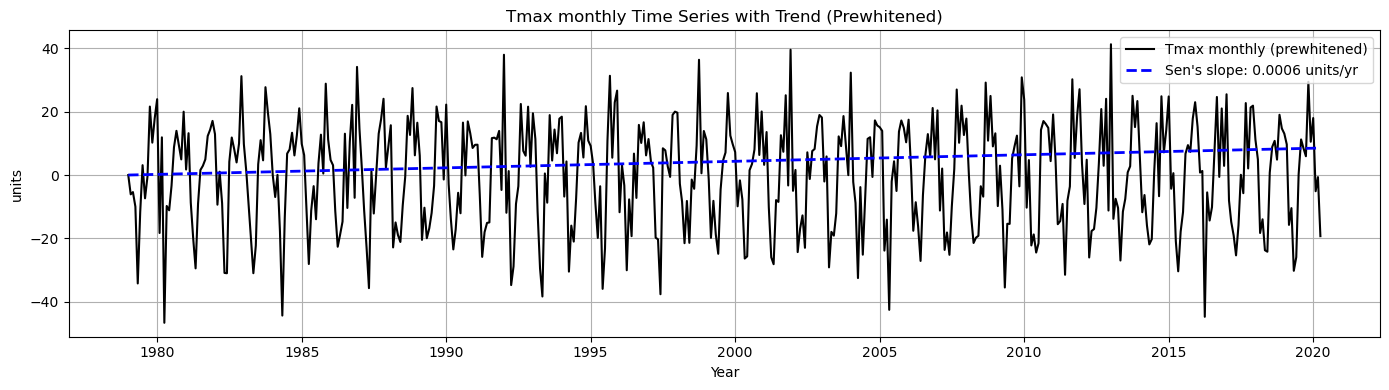


=== Annual trend for Tmax monthly ===
Sen's slope: 0.0070 units/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened

=== Tmin monthly ===


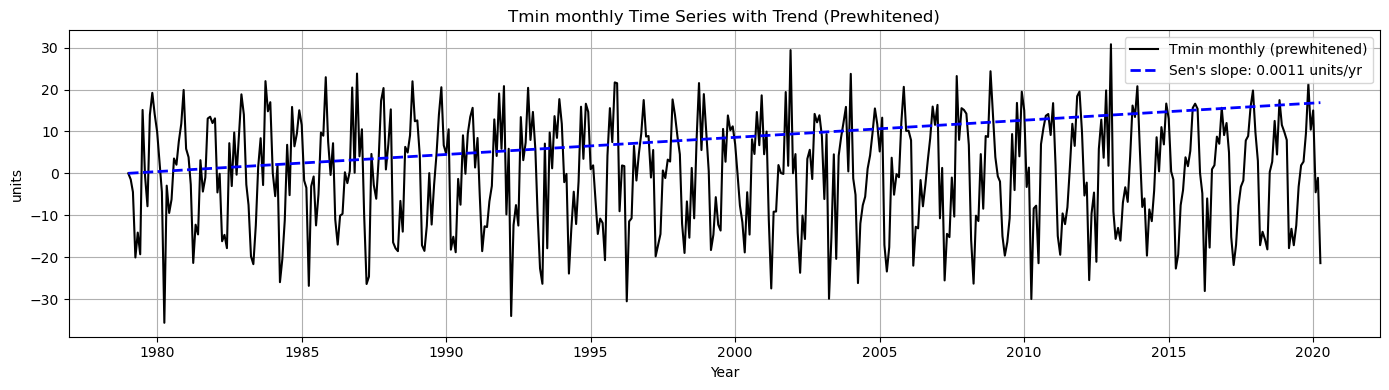


=== Annual trend for Tmin monthly ===
Sen's slope: 0.0073 units/year
Significant (p<0.1)? Yes
Pre-whitening used: Original

=== Streamflow monthly ===


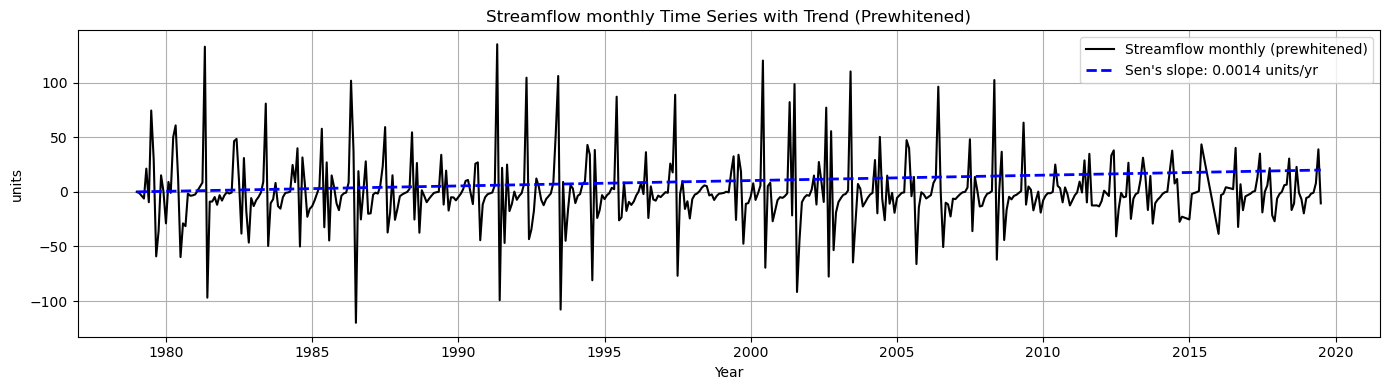


=== Annual trend for Streamflow monthly ===
Sen's slope: -0.0211 units/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened


In [136]:
# ============================================================
# Timeseries Analysis + Trend Plots with Pre-Whitening
# CAMELS-CL Basin 8130002
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import warnings
warnings.filterwarnings("ignore")

# ------------------- FILE PATHS -------------------
datasets = {
    "Precip CR2 monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_cr2met_mon.csv",
    "Precip CHIRPS daily": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_chirps_day.csv",
    "Tmax monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmax_cr2met_mon.csv",
    "Tmin monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmin_cr2met_mon.csv",
    "Streamflow monthly": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/q_m3s_mon.csv"
}

basin_col = '8130002'
date_column = 'date'

# ------------------- FUNCTIONS -------------------

def load_data(filepath, value_col):
    df = pd.read_csv(filepath, parse_dates=[date_column])
    df = df[[date_column, value_col]].dropna()
    df.set_index(date_column, inplace=True)
    return df

def assign_season(df):
    df["month"] = df.index.month
    df["season"] = df["month"].map({
        12:"DJF",1:"DJF",2:"DJF",
        3:"MAM",4:"MAM",5:"MAM",
        6:"JJA",7:"JJA",8:"JJA",
        9:"SON",10:"SON",11:"SON"
    })
    return df

def prewhiten(series):
    lag1 = series.autocorr(lag=1)
    if abs(lag1) > 0.1:
        series_pw = (series.diff().fillna(0)) / (1 - lag1)
        method = "Prewhitened"
    else:
        series_pw = series.copy()
        method = "Original"
    return series_pw, method

def compute_trends(series):
    series_pw, method = prewhiten(series)
    if len(series_pw) > 10:
        test = mk.hamed_rao_modification_test(series_pw.values) if method=="Prewhitened" else mk.original_test(series_pw.values)
        return {
            "sen_slope": test.slope,
            "p_value": test.p,
            "trend": test.trend,
            "significant": test.p < 0.1,
            "n": len(series_pw),
            "method": method,
            "series_pw": series_pw
        }
    else:
        return {"trend":"insufficient data", "series_pw":series_pw}

def plot_timeseries_with_trend(df, value_col, label, units):
    series_pw, method = prewhiten(df[value_col])
    slope = compute_trends(df[value_col])["sen_slope"]
    x = series_pw.index.map(pd.Timestamp.toordinal)
    y_trend = slope*(x - x[0]) + series_pw.iloc[0]
    
    plt.figure(figsize=(14,4))
    plt.plot(series_pw.index, series_pw, color="black", label=f"{label} (prewhitened)")
    plt.plot(series_pw.index, y_trend, linestyle="--", color="blue", linewidth=2, label=f"Sen's slope: {slope:.4f} {units}/yr")
    plt.title(f"{label} Time Series with Trend ({method})")
    plt.ylabel(units)
    plt.xlabel("Year")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

for name, path in datasets.items():
    print(f"\n=== {name} ===")
    df = load_data(path, basin_col)
    df = assign_season(df)
    
    # Timeseries-wide trend plot
    plot_timeseries_with_trend(df, basin_col, name, "units")
    
    # Annual trend print
    annual_series = df.groupby(df.index.year)[basin_col].mean()
    annual_res = compute_trends(annual_series)
    print(f"\n=== Annual trend for {name} ===")
    if annual_res["trend"] != "insufficient data":
        print(f"Sen's slope: {annual_res['sen_slope']:.4f} units/year")
        print(f"Significant (p<0.1)? {'Yes' if annual_res['significant'] else 'No'}")
        print(f"Pre-whitening used: {annual_res['method']}")
    else:
        print("Insufficient data for annual trend.")


## above was using CHIRPS and CR2 precip products. what if we use met station precip measurement (point scale)? 
Here using CR2's station data


=== Precip Las Tancas ===


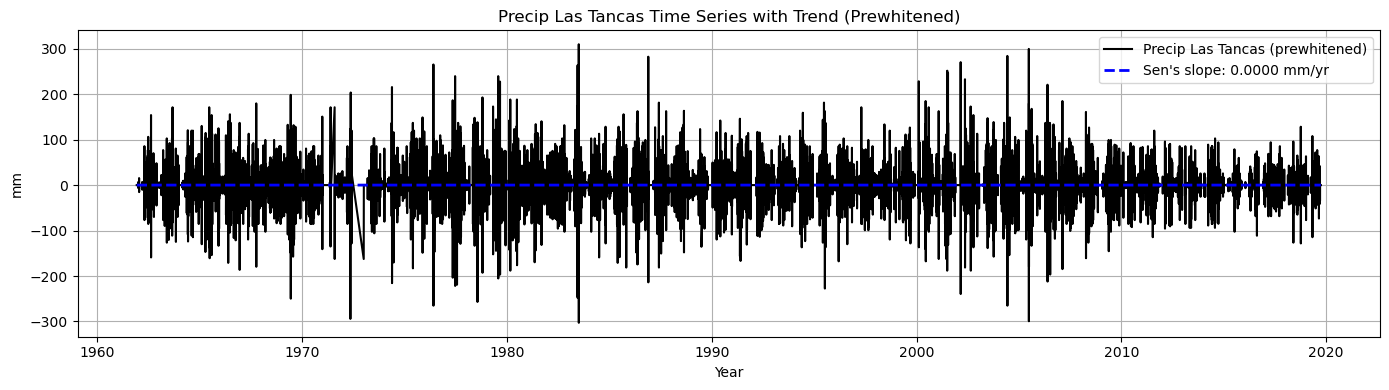


=== Annual trend for Precip Las Tancas ===
Sen's slope: -0.0222 mm/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened

=== Streamflow Diguillin ===


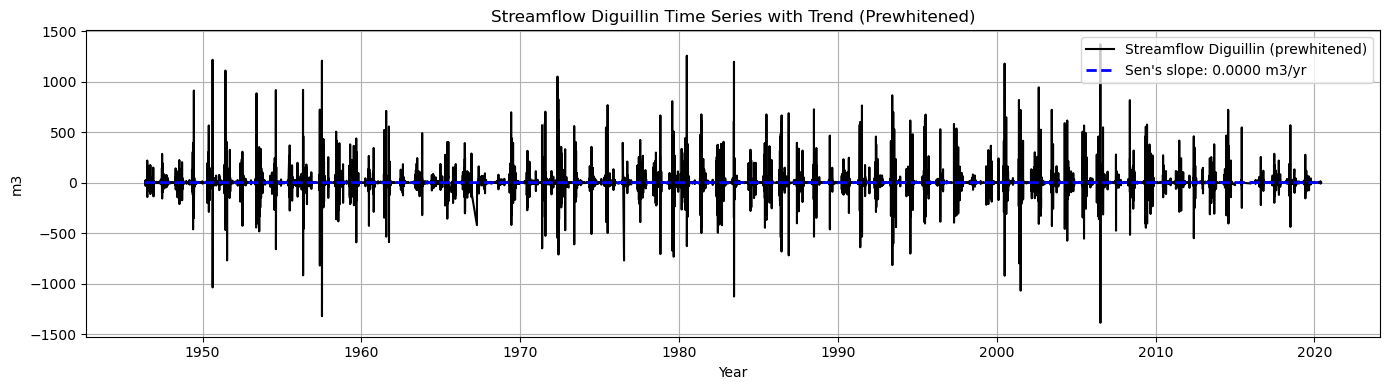


=== Annual trend for Streamflow Diguillin ===
Sen's slope: -0.0026 m3/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened

=== Temperature CR2 ===


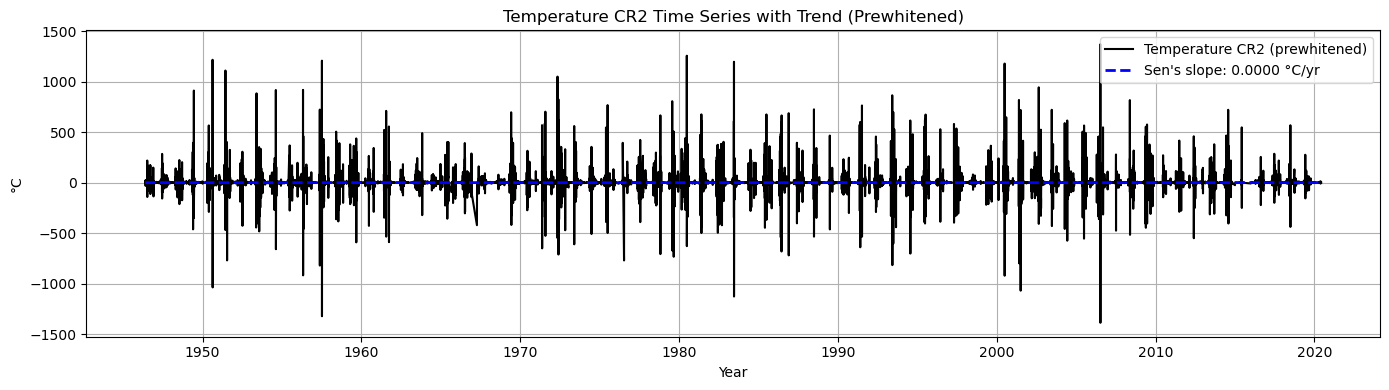


=== Annual trend for Temperature CR2 ===
Sen's slope: -0.0026 °C/year
Significant (p<0.1)? No
Pre-whitening used: Prewhitened


In [148]:
# ============================================================
# Trend Analysis + Timeseries Plots with Pre-Whitening
# CAMELS-CL + Additional Sites
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk
import warnings
warnings.filterwarnings("ignore")

# ------------------- FILE PATHS -------------------
datasets = {
    "Precip Las Tancas": "/Users/milliespencer/Downloads/precip_lastrancas.csv",
    "Streamflow Diguillin": "/Users/milliespencer/Downloads/streamflow_diguillin.csv",
    "Temperature CR2": "/Users/milliespencer/Downloads/temp_series_cr2.csv"
}

# Column names in the CSVs
# Precip: 'value [mm]'
# Streamflow: 'value [m3]'
# Temp: 'value [°C]'
value_col_daily = {
    "Precip Las Tancas": "value [mm]",
    "Streamflow Diguillin": "value [m3]",
    "Temperature CR2": "value [°C]"
}

# ------------------- FUNCTIONS -------------------

def load_data(filepath, value_col):
    """Load CSV, clean column names, construct datetime from year, month, day, return dataframe indexed by date and cleaned column name."""
    # Try reading UTF-8, fallback to latin1
    try:
        df = pd.read_csv(filepath)
    except UnicodeDecodeError:
        df = pd.read_csv(filepath, encoding='latin1')
    
    # Strip whitespace and remove special characters
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)
    
    # Clean value_col to match cleaned column name
    value_col_clean = ''.join(c for c in value_col if c.isalnum() or c==' ').strip()
    
    # Construct datetime
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
    
    df = df[['date', value_col_clean]].dropna()
    df.set_index('date', inplace=True)
    
    return df, value_col_clean

def assign_season(df):
    """Assign month and meteorological season."""
    df["month"] = df.index.month
    df["season"] = df["month"].map({
        12:"DJF",1:"DJF",2:"DJF",
        3:"MAM",4:"MAM",5:"MAM",
        6:"JJA",7:"JJA",8:"JJA",
        9:"SON",10:"SON",11:"SON"
    })
    return df

def prewhiten(series):
    """Apply pre-whitening if lag-1 autocorrelation is > 0.1."""
    lag1 = series.autocorr(lag=1)
    if abs(lag1) > 0.1:
        series_pw = (series.diff().fillna(0)) / (1 - lag1)
        method = "Prewhitened"
    else:
        series_pw = series.copy()
        method = "Original"
    return series_pw, method

def compute_trends(series):
    """Compute Sen's slope and Mann-Kendall trend, using pre-whitening if needed."""
    series_pw, method = prewhiten(series)
    if len(series_pw) > 10:
        test = mk.hamed_rao_modification_test(series_pw.values) if method=="Prewhitened" else mk.original_test(series_pw.values)
        return {
            "sen_slope": test.slope,
            "p_value": test.p,
            "trend": test.trend,
            "significant": test.p < 0.1,
            "n": len(series_pw),
            "method": method,
            "series_pw": series_pw
        }
    else:
        return {"trend":"insufficient data", "series_pw":series_pw}

def plot_timeseries_with_trend(df, value_col, label, units):
    """Plot time series with prewhitened data and Sen's slope trend line."""
    series_pw, method = prewhiten(df[value_col])
    slope = compute_trends(df[value_col])["sen_slope"]
    x = series_pw.index.map(pd.Timestamp.toordinal)
    y_trend = slope*(x - x[0]) + series_pw.iloc[0]
    
    plt.figure(figsize=(14,4))
    plt.plot(series_pw.index, series_pw, color="black", label=f"{label} (prewhitened)")
    plt.plot(series_pw.index, y_trend, linestyle="--", color="blue", linewidth=2,
             label=f"Sen's slope: {slope:.4f} {units}/yr")
    plt.title(f"{label} Time Series with Trend ({method})")
    plt.ylabel(units)
    plt.xlabel("Year")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- RUN ANALYSIS -------------------

for dataset_name, path in datasets.items():
    print(f"\n=== {dataset_name} ===")
    value_col = value_col_daily[dataset_name]
    
    # Load data
    df, value_col_clean = load_data(path, value_col)
    df = assign_season(df)
    
    # Timeseries-wide trend
    plot_timeseries_with_trend(df, value_col_clean, dataset_name, value_col.split("[")[-1].replace("]","").strip())
    
    # Annual trend print
    annual_res = compute_trends(df.groupby(df.index.year)[value_col_clean].mean())
    print(f"\n=== Annual trend for {dataset_name} ===")
    if annual_res["trend"] != "insufficient data":
        print(f"Sen's slope: {annual_res['sen_slope']:.4f} {value_col.split('[')[-1].replace(']','').strip()}/year")
        print(f"Significant (p<0.1)? {'Yes' if annual_res['significant'] else 'No'}")
        print(f"Pre-whitening used: {annual_res['method']}")
    else:
        print("Insufficient data for annual trend.")


## Simple OLS analysis of CAMELS-C: gridded data (no pre-whitening):


=== Daily Precipitation CHIRPS ===

-- Before / After 2000 --


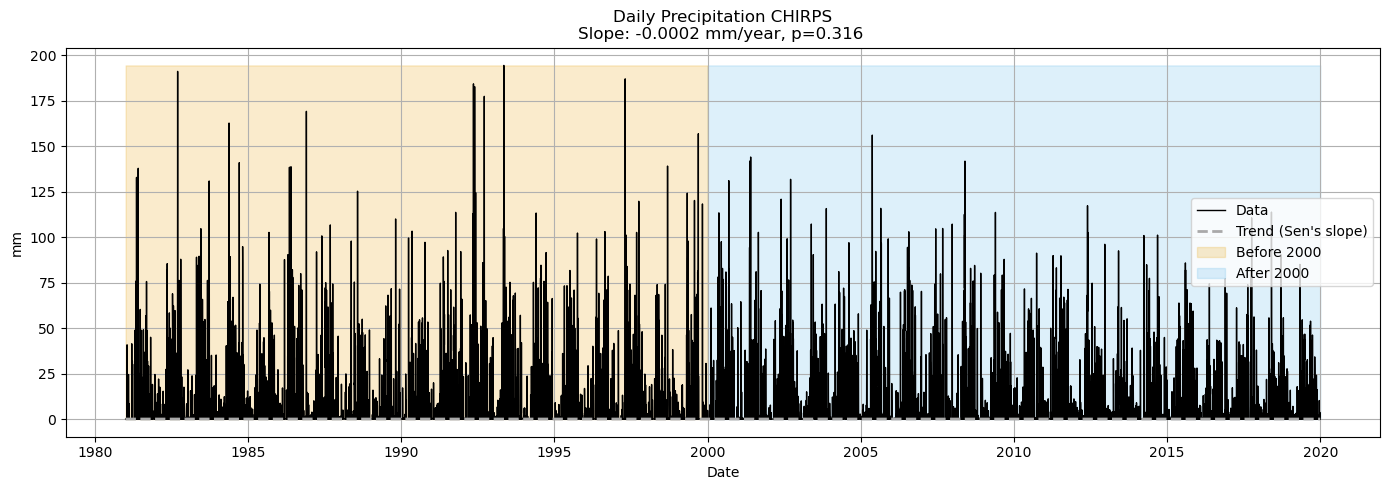

Mean for Before 2000 (1981-01-01 to 1999-12-31): 5.947 mm
Mean for After 2000 (2000-01-01 to 2019-12-31): 5.780 mm

Percent changes between consecutive periods:
  After 2000 vs Before 2000: -2.79%

-- Decadal Means --


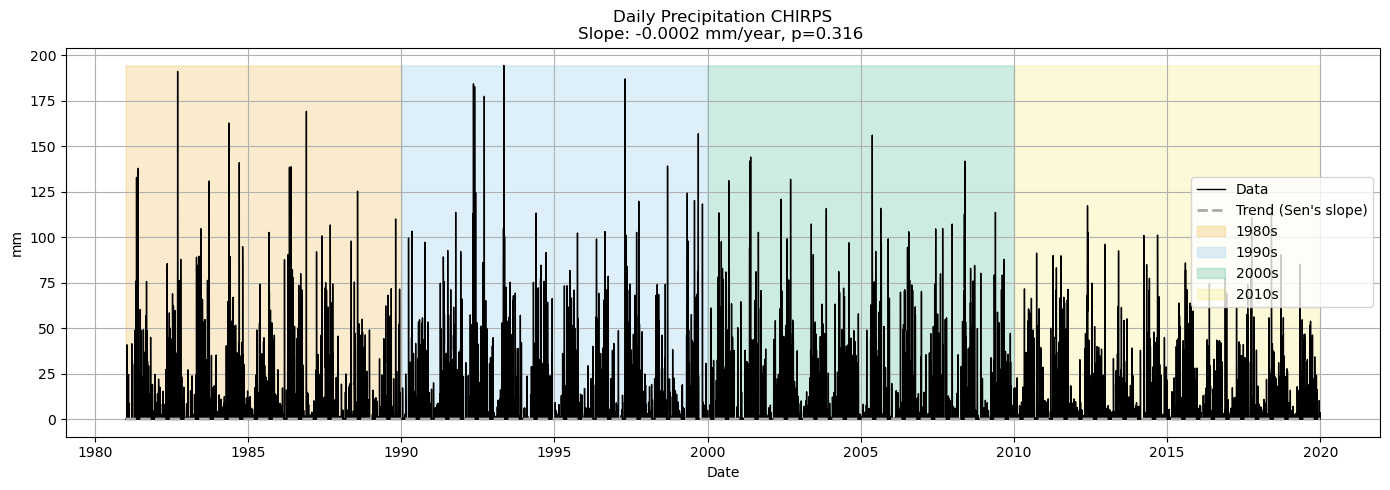

Mean for 1980s (1981-01-01 to 1989-12-31): 5.908 mm
Mean for 1990s (1990-01-01 to 1999-12-31): 5.981 mm
Mean for 2000s (2000-01-01 to 2009-12-31): 6.711 mm
Mean for 2010s (2010-01-01 to 2019-12-31): 4.850 mm

Percent changes between consecutive periods:
  1990s vs 1980s: 1.24%
  2000s vs 1990s: 12.19%
  2010s vs 2000s: -27.73%

=== Annual Trend for Daily Precipitation CHIRPS ===
Sen's slope: 0.0000 mm/year
Mann-Kendall p-value: 0.316 (not significant)

=== Monthly Precipitation CR2MET ===

-- Before / After 2000 --


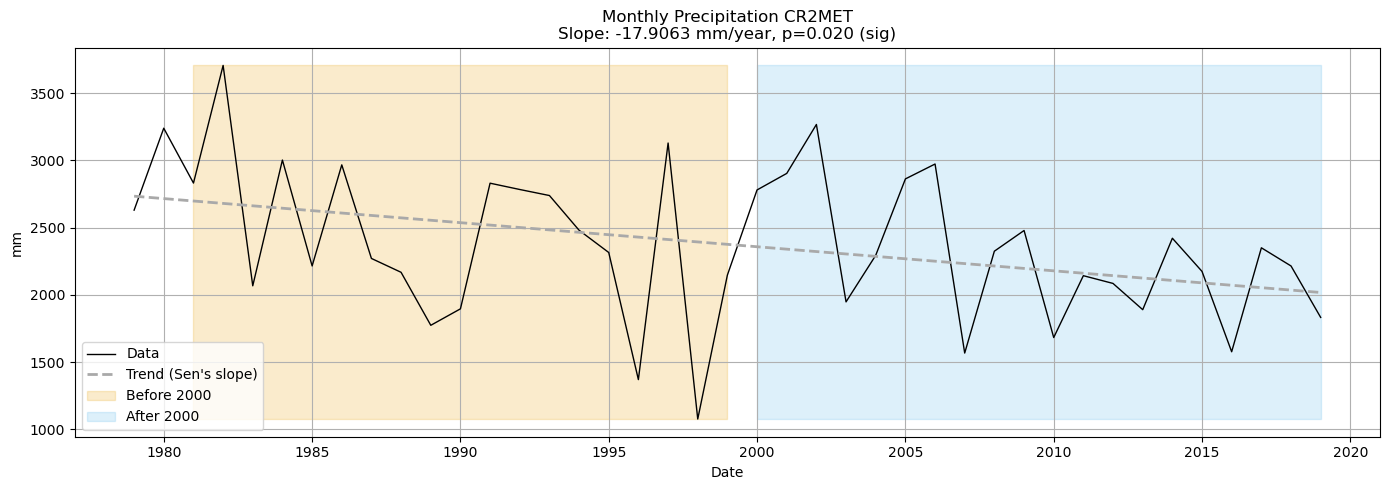

Mean for Before 2000 (1981-01-01 to 1999-12-31): 2408.709 mm
Mean for After 2000 (2000-01-01 to 2019-12-31): 2288.198 mm

Percent changes between consecutive periods:
  After 2000 vs Before 2000: -5.00%

-- Decadal Means --


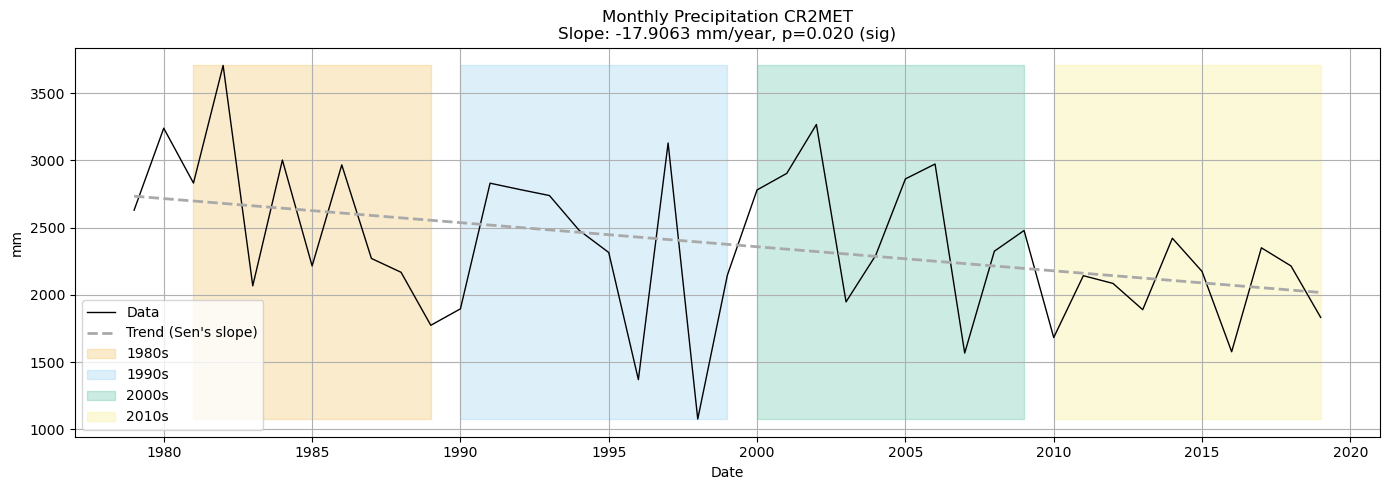

Mean for 1980s (1981-01-01 to 1989-12-31): 2555.593 mm
Mean for 1990s (1990-01-01 to 1999-12-31): 2276.514 mm
Mean for 2000s (2000-01-01 to 2009-12-31): 2539.646 mm
Mean for 2010s (2010-01-01 to 2019-12-31): 2036.751 mm

Percent changes between consecutive periods:
  1990s vs 1980s: -10.92%
  2000s vs 1990s: 11.56%
  2010s vs 2000s: -19.80%

=== Annual Trend for Monthly Precipitation CR2MET ===
Sen's slope: -19.3651 mm/year
Mann-Kendall p-value: 0.020 (significant)

=== Max Temperature (Tmax) ===

-- Before / After 2000 --


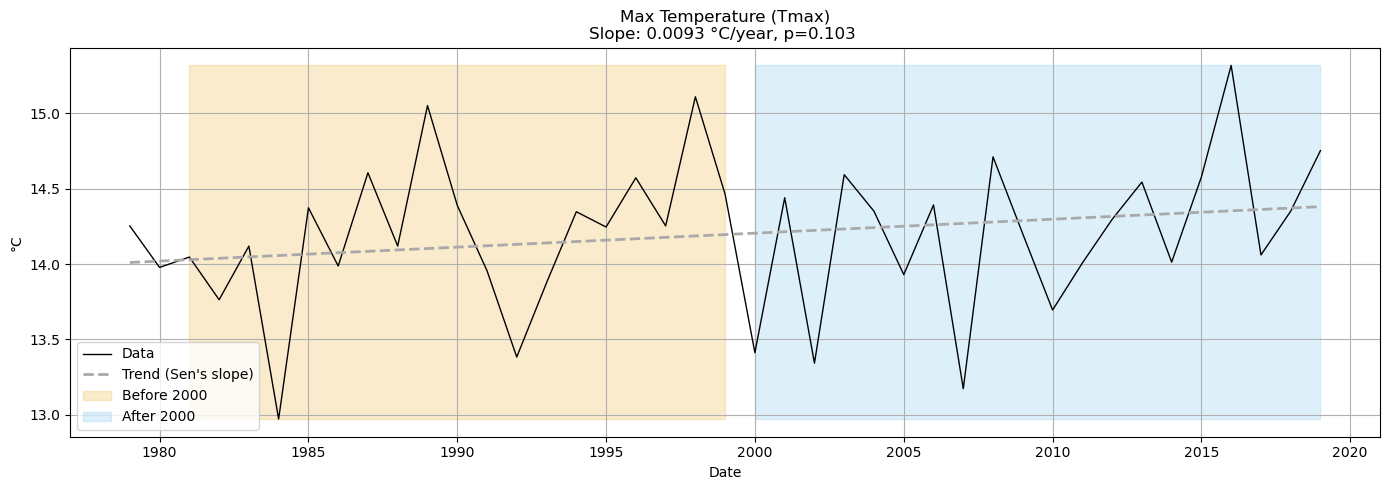

Mean for Before 2000 (1981-01-01 to 1999-12-31): 14.191 °C
Mean for After 2000 (2000-01-01 to 2019-12-31): 14.208 °C

Percent changes between consecutive periods:
  After 2000 vs Before 2000: 0.12%

-- Decadal Means --


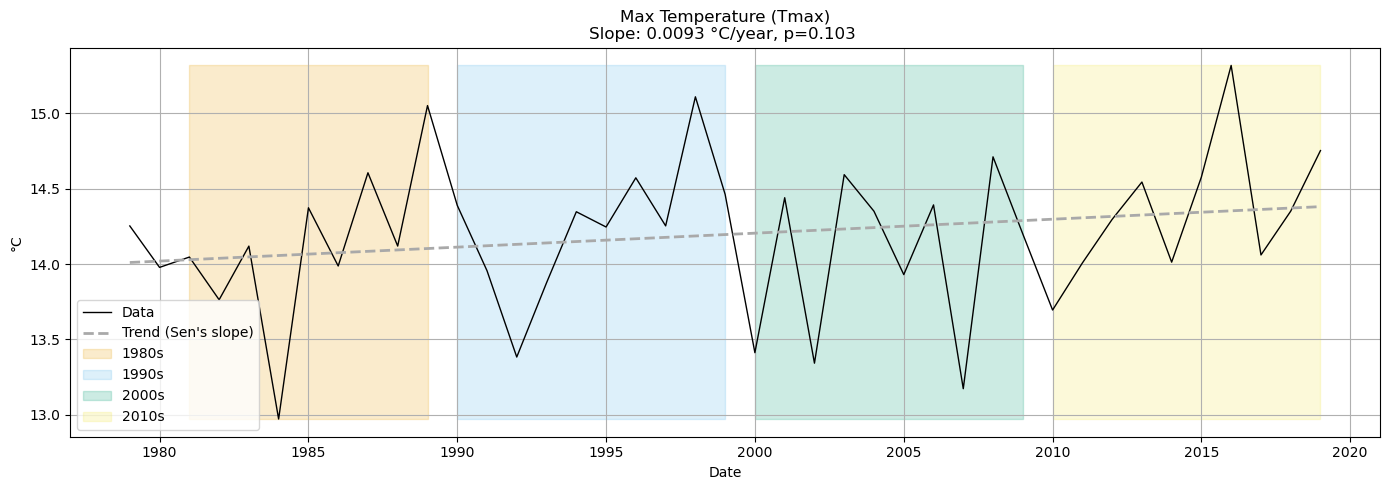

Mean for 1980s (1981-01-01 to 1989-12-31): 14.115 °C
Mean for 1990s (1990-01-01 to 1999-12-31): 14.260 °C
Mean for 2000s (2000-01-01 to 2009-12-31): 14.054 °C
Mean for 2010s (2010-01-01 to 2019-12-31): 14.362 °C

Percent changes between consecutive periods:
  1990s vs 1980s: 1.02%
  2000s vs 1990s: -1.44%
  2010s vs 2000s: 2.19%

=== Annual Trend for Max Temperature (Tmax) ===
Sen's slope: 0.0091 °C/year
Mann-Kendall p-value: 0.103 (not significant)

=== Min Temperature (Tmin) ===

-- Before / After 2000 --


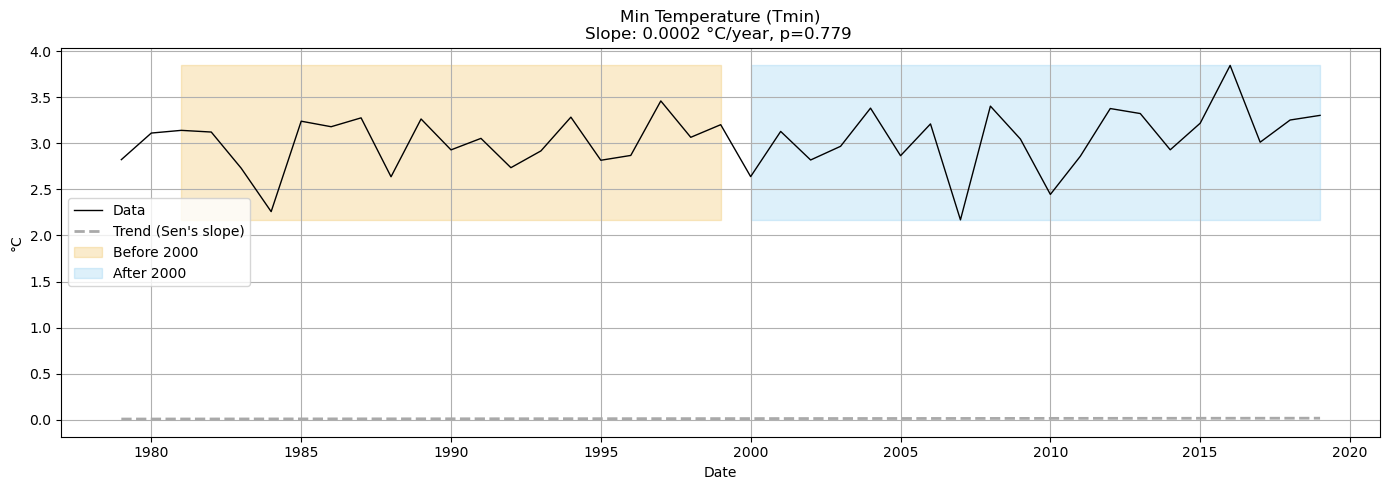

Mean for Before 2000 (1981-01-01 to 1999-12-31): 3.011 °C
Mean for After 2000 (2000-01-01 to 2019-12-31): 3.061 °C

Percent changes between consecutive periods:
  After 2000 vs Before 2000: 1.68%

-- Decadal Means --


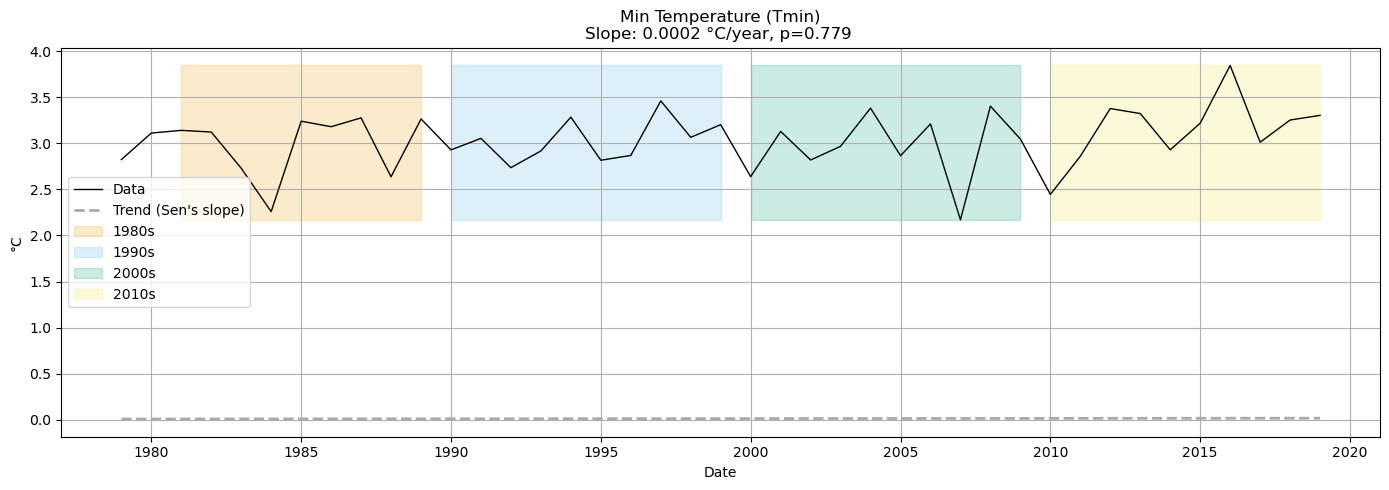

Mean for 1980s (1981-01-01 to 1989-12-31): 2.985 °C
Mean for 1990s (1990-01-01 to 1999-12-31): 3.035 °C
Mean for 2000s (2000-01-01 to 2009-12-31): 2.965 °C
Mean for 2010s (2010-01-01 to 2019-12-31): 3.158 °C

Percent changes between consecutive periods:
  1990s vs 1980s: 1.68%
  2000s vs 1990s: -2.31%
  2010s vs 2000s: 6.54%

=== Annual Trend for Min Temperature (Tmin) ===
Sen's slope: 0.0016 °C/year
Mann-Kendall p-value: 0.779 (not significant)

=== Monthly Streamflow ===

-- Before / After 2000 --


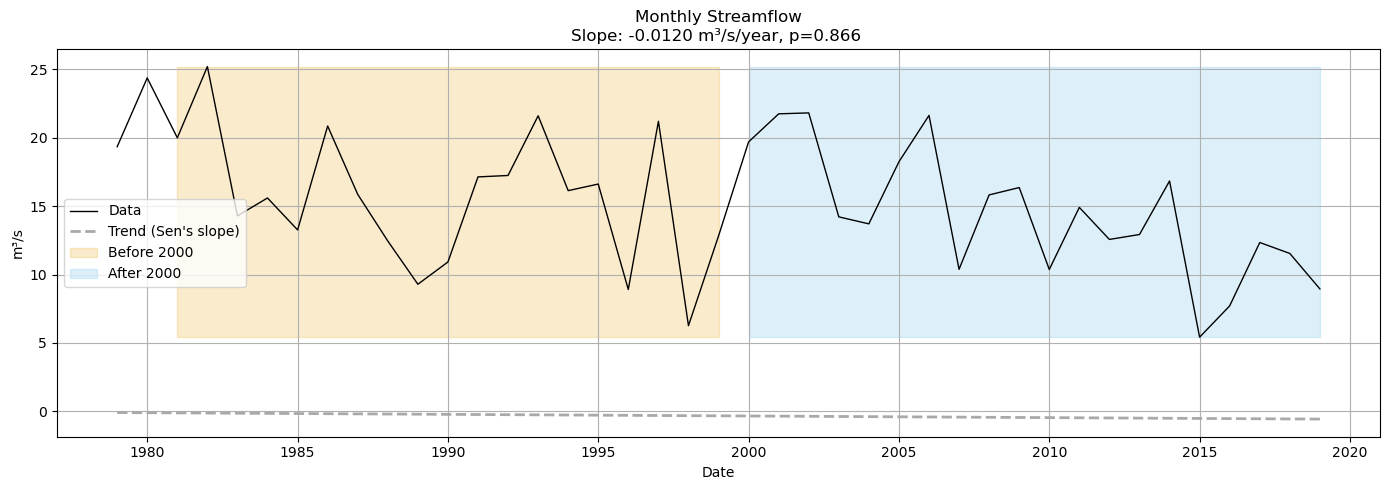

Mean for Before 2000 (1981-01-01 to 1999-12-31): 15.563 m³/s
Mean for After 2000 (2000-01-01 to 2019-12-31): 14.362 m³/s

Percent changes between consecutive periods:
  After 2000 vs Before 2000: -7.72%

-- Decadal Means --


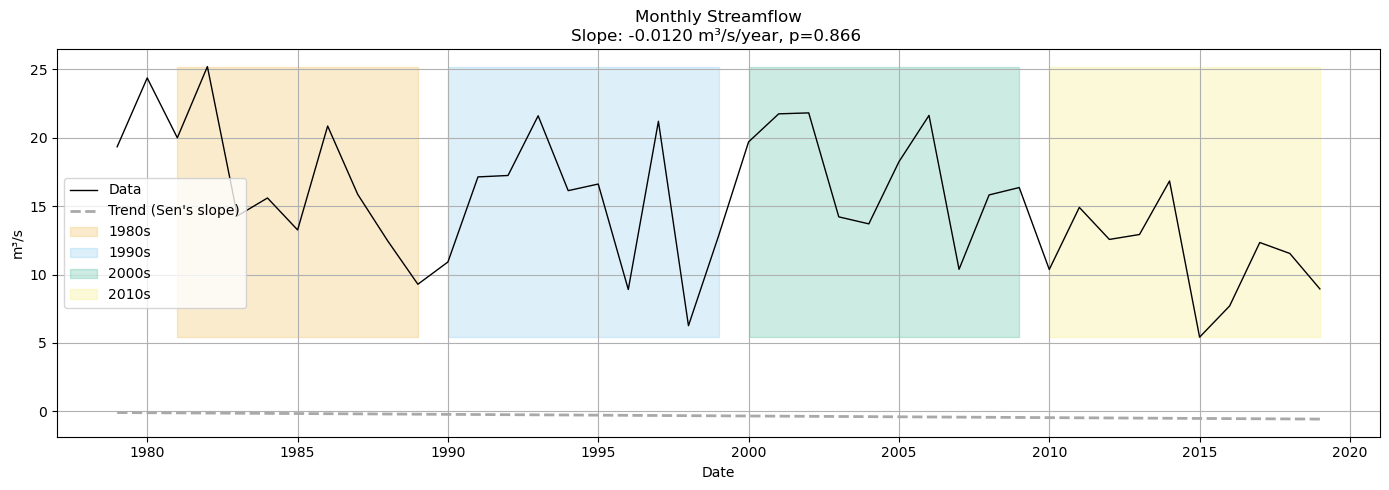

Mean for 1980s (1981-01-01 to 1989-12-31): 16.316 m³/s
Mean for 1990s (1990-01-01 to 1999-12-31): 14.886 m³/s
Mean for 2000s (2000-01-01 to 2009-12-31): 17.366 m³/s
Mean for 2010s (2010-01-01 to 2019-12-31): 11.357 m³/s

Percent changes between consecutive periods:
  1990s vs 1980s: -8.76%
  2000s vs 1990s: 16.66%
  2010s vs 2000s: -34.60%

=== Annual Trend for Monthly Streamflow ===
Sen's slope: -0.0209 m³/s/year
Mann-Kendall p-value: 0.866 (not significant)


In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pymannkendall as mk
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson

# ------------------- FILE PATHS -------------------
daily_precip_chirps = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_chirps_day.csv'
monthly_precip_cr2 = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/precip_cr2met_mon.csv'
tmax_monthly = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmax_cr2met_mon.csv'
tmin_monthly = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/tmin_cr2met_mon.csv'
streamflow_monthly = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/camels_cl_8130002/q_m3s_mon.csv'

basin_col = '8130002'
date_column = 'date'
exclude_years = [2020]

# ------------------- FUNCTIONS -------------------

def load_and_prepare(file, basin_col, new_colname, monthly=False):
    """Load CSV and optionally aggregate to annual values."""
    df = pd.read_csv(file, parse_dates=[date_column])
    df = df[[date_column, basin_col]].dropna()
    
    df['year'] = df[date_column].dt.year
    df = df[~df['year'].isin(exclude_years)]
    
    if monthly:
        # Aggregate per year
        if 'precip' in new_colname.lower() or 'q' in new_colname.lower():
            df_agg = df.groupby('year')[basin_col].sum()
        else:
            df_agg = df.groupby('year')[basin_col].mean()
        df_agg.index = pd.to_datetime(df_agg.index.astype(str))
        df = df_agg.to_frame(name=new_colname)
    else:
        df = df.rename(columns={basin_col: new_colname})
        df.set_index(date_column, inplace=True)
    
    return df

def prewhiten_series(series):
    """Prewhiten series if lag-1 autocorrelation > 0.1."""
    y = series.values
    lag1 = acf(y, nlags=1, fft=False)[1]
    if abs(lag1) > 0.1:
        y_pw = series.diff().fillna(0) / (1 - lag1)
        return pd.Series(y_pw, index=series.index), True
    else:
        return series, False

def compute_sen_mk_trend(series):
    """Compute Sen's slope and Mann-Kendall test, after prewhitening if needed."""
    series_pw, prewhitened = prewhiten_series(series)
    result = mk.original_test(series_pw.values)  # Sen's + MK
    return result, prewhitened

def linear_trend_line(series):
    """Return fitted trend line from linear regression."""
    x = series.index.map(pd.Timestamp.toordinal).values.reshape(-1,1)
    y = series.values.reshape(-1,1)
    model = LinearRegression()
    model.fit(x, y)
    trend = model.predict(x)
    slope_per_day = model.coef_[0][0]
    return trend, slope_per_day

def plot_with_trends_and_periods(df, title, ylabel, periods, cb_palette):
    """Plot time series with prewhitened trend, shading periods, and mean changes."""
    # Prewhiten for plotting trend
    series = df.iloc[:,0]
    series_pw, prewhitened = prewhiten_series(series)
    
    # Compute Sen + MK trend
    mk_res, _ = compute_sen_mk_trend(series)
    
    # Linear trend line for visual
    trend_line, slope_per_day = linear_trend_line(series_pw)
    slope_per_year = slope_per_day * 365.25
    
    plt.figure(figsize=(14,5))
    plt.plot(series.index, series, color='black', lw=1, label='Data')
    plt.plot(series.index, trend_line, '--', color='darkgrey', lw=2, label=f"Trend (Sen's slope)")
    
    # Period shading
    for i, (start, end, label, col) in enumerate(periods):
        plt.fill_between(series.index, series.min(), series.max(),
                         where=(series.index>=start) & (series.index<=end),
                         color=cb_palette[i % len(cb_palette)], alpha=0.2, label=label)
    
    plt.title(f"{title}\nSlope: {slope_per_year:.4f} {ylabel}/year, p={mk_res.p:.3f} {'(sig)' if mk_res.p<0.1 else ''}")
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Compute means and percent changes per period
    means = {}
    for start, end, label, _ in periods:
        period_mean = series.loc[(series.index>=start) & (series.index<=end)].mean()
        means[label] = period_mean
        print(f"Mean for {label} ({start.date()} to {end.date()}): {period_mean:.3f} {ylabel}")
    
    labels = list(means.keys())
    print("\nPercent changes between consecutive periods:")
    for i in range(len(labels)-1):
        pct_change = ((means[labels[i+1]] - means[labels[i]]) / means[labels[i]] * 100
                     if means[labels[i]] != 0 else float('nan'))
        print(f"  {labels[i+1]} vs {labels[i]}: {pct_change:.2f}%")
    
# ------------------- RUN ANALYSIS -------------------

datasets = {
    'Daily Precipitation CHIRPS': (daily_precip_chirps, 'mm', False),
    'Monthly Precipitation CR2MET': (monthly_precip_cr2, 'mm', True),
    'Max Temperature (Tmax)': (tmax_monthly, '°C', True),
    'Min Temperature (Tmin)': (tmin_monthly, '°C', True),
    'Monthly Streamflow': (streamflow_monthly, 'm³/s', True),
}

# Color-blind friendly palette (black-and-white friendly)
cb_palette = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#999999']

before_after_2000 = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1999-12-31'), 'Before 2000', cb_palette[0]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2019-12-31'), 'After 2000', cb_palette[1]),
]

decades = [
    (pd.Timestamp('1981-01-01'), pd.Timestamp('1989-12-31'), '1980s', cb_palette[2]),
    (pd.Timestamp('1990-01-01'), pd.Timestamp('1999-12-31'), '1990s', cb_palette[3]),
    (pd.Timestamp('2000-01-01'), pd.Timestamp('2009-12-31'), '2000s', cb_palette[4]),
    (pd.Timestamp('2010-01-01'), pd.Timestamp('2019-12-31'), '2010s', cb_palette[5]),
]

for name, (filepath, units, monthly) in datasets.items():
    print(f"\n=== {name} ===")
    df = load_and_prepare(filepath, basin_col, name, monthly=monthly)
    
    print("\n-- Before / After 2000 --")
    plot_with_trends_and_periods(df, name, units, before_after_2000, cb_palette)
    
    print("\n-- Decadal Means --")
    plot_with_trends_and_periods(df, name, units, decades, cb_palette)
    
    # Annual trend summary
    series = df.iloc[:,0]
    mk_res, prewhitened = compute_sen_mk_trend(series)
    slope_per_year = mk_res.slope
    print(f"\n=== Annual Trend for {name} ===")
    print(f"Sen's slope: {slope_per_year:.4f} {units}/year")
    print(f"Mann-Kendall p-value: {mk_res.p:.3f} {'(significant)' if mk_res.p<0.1 else '(not significant)'}")


# Compare CHIRPS and CR2 precipitation datasets: 

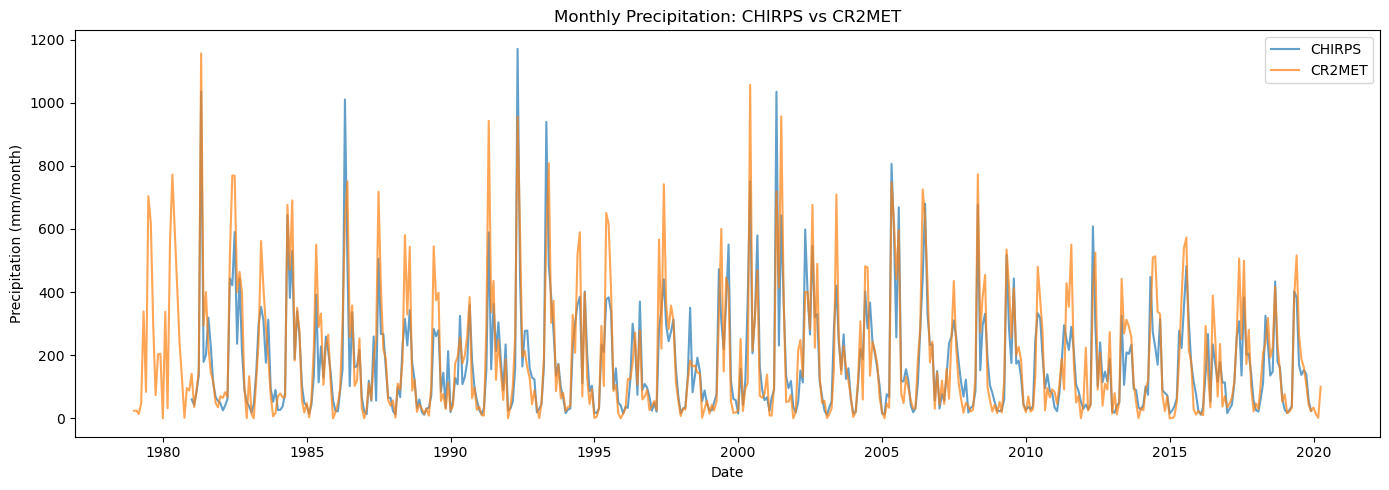

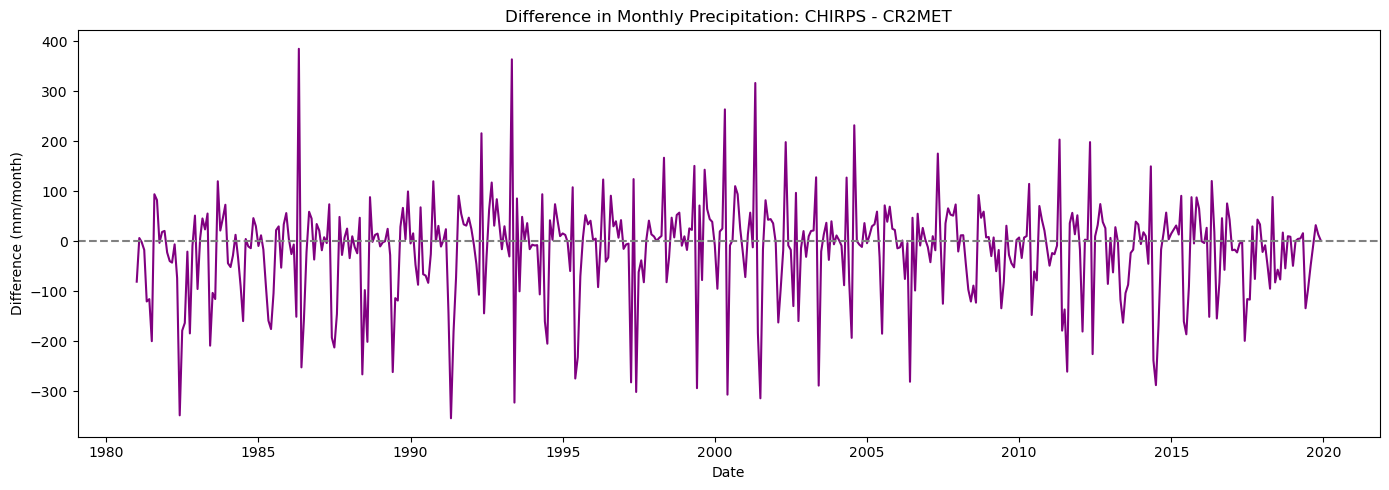

=== Monthly Precipitation Comparison ===
Mean CHIRPS: 178.39493589743586
Mean CR2MET: 197.96434114816157
Mean Difference (CHIRPS - CR2MET): -17.180803424890787


In [ ]:
# === Load data ===
def load_precip(path, basin_col='8130002', new_colname='precip'):
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.rename(columns={basin_col: new_colname})
    return df[['date', new_colname]]

df_monthly_chirps = load_precip(monthly_precip_chirps, new_colname='chirps')
df_monthly_cr2 = load_precip(monthly_precip_cr2, new_colname='cr2')

# === Plot Monthly Comparison ===
plt.figure(figsize=(14, 5))
plt.plot(df_monthly_chirps['date'], df_monthly_chirps['chirps'], label='CHIRPS', alpha=0.7)
plt.plot(df_monthly_cr2['date'], df_monthly_cr2['cr2'], label='CR2MET', alpha=0.7)
plt.title('Monthly Precipitation: CHIRPS vs CR2MET')
plt.ylabel('Precipitation (mm/month)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# === Difference Over Time (Monthly) ===
df_monthly = pd.merge(df_monthly_chirps, df_monthly_cr2, on='date', how='inner')
df_monthly['difference'] = df_monthly['chirps'] - df_monthly['cr2']

plt.figure(figsize=(14, 5))
plt.plot(df_monthly['date'], df_monthly['difference'], color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Difference in Monthly Precipitation: CHIRPS - CR2MET')
plt.ylabel('Difference (mm/month)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# === Summary Stats ===
print("=== Monthly Precipitation Comparison ===")
print("Mean CHIRPS:", df_monthly['chirps'].mean())
print("Mean CR2MET:", df_monthly['cr2'].mean())
print("Mean Difference (CHIRPS - CR2MET):", df_monthly['difference'].mean())


## CR2met mean monthly precipitation is about 17mm grater than that reported by CHIRPS 